Nom : 
- AGBOSSOU SESSOU Hola Anne-Stéphanie
- DUEVI-TSIBIAKU koko Bertille

Filère : IA et Big Data

# Projet de détection d'anomalies bancaires avec K-means

Ce notebook présente une solution étape par étape pour détecter des transactions inhabituelles dans un jeu de données de transactions bancaires synthétiques. Nous utilisons K-means pour regrouper les comportements et identifier les transactions dont la distance au centroïde est trop élevée.

Objectifs :
- charger et inspecter les données
- sélectionner et normaliser les caractéristiques pertinentes
- appliquer K-means avec 6 clusters
- détecter les anomalies selon un seuil de distance
- visualiser les résultats et analyser les clusters


# Etape 1 : Chargement des données

In [35]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [36]:
def load_data(file_path: str) -> pd.DataFrame:
    
    # Charger le jeu de données de transactions depuis le fichier CSV.
    
    df = pd.read_csv(file_path)
    return df


In [46]:
df_transaction = load_data('transactions.csv')
print("Dimensions du dataset :", df_transaction.shape)
print("Colonnes:", list(df_transaction.columns))
print("Valeurs manquantes par colonne:\n", df_transaction.isna().sum())
df_transaction.head()

Dimensions du dataset : (20000, 8)
Colonnes: ['global_id', 'sender_id', 'receiver_id', 'initial_amount', 'transfer_amount', 'amount_received', 'final_amount', 'date']
Valeurs manquantes par colonne:
 global_id          0
sender_id          0
receiver_id        0
initial_amount     0
transfer_amount    0
amount_received    0
final_amount       0
date               0
dtype: int64


,global_id,sender_id,receiver_id,initial_amount,transfer_amount,amount_received,final_amount,date
0,1,417,583,102.332066,11.004279,11.004279,91.327787,2021-10-07 12:16:55.521706
1,2,68,277,83.130697,6.325441,6.325441,76.805256,2023-08-16 00:26:54.521999
2,3,621,546,96.091707,2.435575,2.435575,93.656132,2024-03-26 11:50:51.518583
3,4,783,337,82.476615,13.056381,13.056381,69.420234,2025-01-30 13:57:10.355813
4,5,255,327,92.090839,19.036857,19.036857,73.053982,2020-06-13 12:35:59.742668


## Etape 2 : Sélection des caractéristiques pertinentes 

In [38]:
# les colonnes utiles pour la détection d’anomalies

def select_features(df: pd.DataFrame) -> pd.DataFrame:
    
    # Sélection des caractéristiques numériques pertinentes pour le clustering.

    features = [
        "initial_amount",
        "transfer_amount",
        "amount_received",
        "final_amount"
    ]

    selected = df[features].copy()
    selected = selected.dropna()

    return selected

df_features = select_features(df_transaction)
df_features.head()


,initial_amount,transfer_amount,amount_received,final_amount
0,102.332066,11.004279,11.004279,91.327787
1,83.130697,6.325441,6.325441,76.805256
2,96.091707,2.435575,2.435575,93.656132
3,82.476615,13.056381,13.056381,69.420234
4,92.090839,19.036857,19.036857,73.053982


## Étape 3 : Préparation et normalisation des données

In [40]:
# Normalisation des données

def normalize_features(df: pd.DataFrame) -> np.ndarray:
    
    # Normalisation des caractéristiques sélectionnées avec StandardScaler.

    
    scaler = StandardScaler()
    normalized_data = scaler.fit_transform(df)
    return normalized_data


## Étape 4 : Clustering avec K-means

In [41]:
# Application de KMeans

def apply_kmeans(data: np.ndarray,
                 n_clusters: int = 6) -> tuple:
    
    # Application de KMeans aux données normalisées.

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(data)
    return model, labels


## Étape 5 : Détection des anomalies

In [42]:
# Détection d’anomalies
def detect_anomalies(data: np.ndarray,
                     model: KMeans,
                     threshold: float) -> np.ndarray:
    
    # Détection des transactions dont la distance au centroïde est supérieure au seuil.

    centroids = model.cluster_centers_
    labels = model.labels_

    anomalies = []
    for i in range(len(data)):
        cluster_id = labels[i]
        centroid = centroids[cluster_id]
        distance = np.linalg.norm(data[i] - centroid)
        if distance > threshold:
            anomalies.append(i)

    return np.array(anomalies)


## Étape 6 : Affichage des résultats

In [43]:
# Visualisation des clusters et des anomalies + réduction de dimension avec PCA

def plot_clusters(data: np.ndarray,
                  labels: np.ndarray,
                  anomalies: np.ndarray):

    # Affichage des clusters en 2 dimensions et mise en évidence des anomalies.

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    plt.figure(figsize=(16, 10))
    plt.scatter(
        reduced[:, 0],
        reduced[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.6
    )

    plt.scatter(
        reduced[anomalies, 0],
        reduced[anomalies, 1],
        color="red",
        s=50,
        label="Anomalies"
    )

    plt.title("Détection d'anomalies avec K-Means")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.show()


### Fonction d'analyse des clusters

Cette fonction calcule les statistiques de chaque cluster et le nombre d'anomalies par groupe afin de faciliter l'interprétation des résultats.


In [47]:
def analyze_clusters(df: pd.DataFrame, labels: np.ndarray, anomalies: np.ndarray) -> pd.DataFrame:
    summary = df.copy().reset_index(drop=True)
    summary["cluster"] = labels
    summary["is_anomaly"] = False
    summary.iloc[anomalies, summary.columns.get_loc("is_anomaly")] = True

    report = summary.groupby("cluster").agg(
        transactions=("initial_amount", "size"),
        initial_amount_mean=("initial_amount", "mean"),
        transfer_amount_mean=("transfer_amount", "mean"),
        amount_received_mean=("amount_received", "mean"),
        final_amount_mean=("final_amount", "mean"),
        anomalies=("is_anomaly", "sum")
    ).reset_index()

    display(report)
    return report

## Étape 7 : Script principal (main)

Le script principal exécute toutes les étapes du projet : lecture des données, sélection des caractéristiques, normalisation, clustering, détection des anomalies et visualisation.


Features sélectionnées : (20000, 4)
Seuil de distance choisi (99e percentile) : 1.589
Nombre d'anomalies : 200
Distribution des clusters :
0    13429
1      967
2     3076
3      985
4      819
5      724
Name: count, dtype: int64


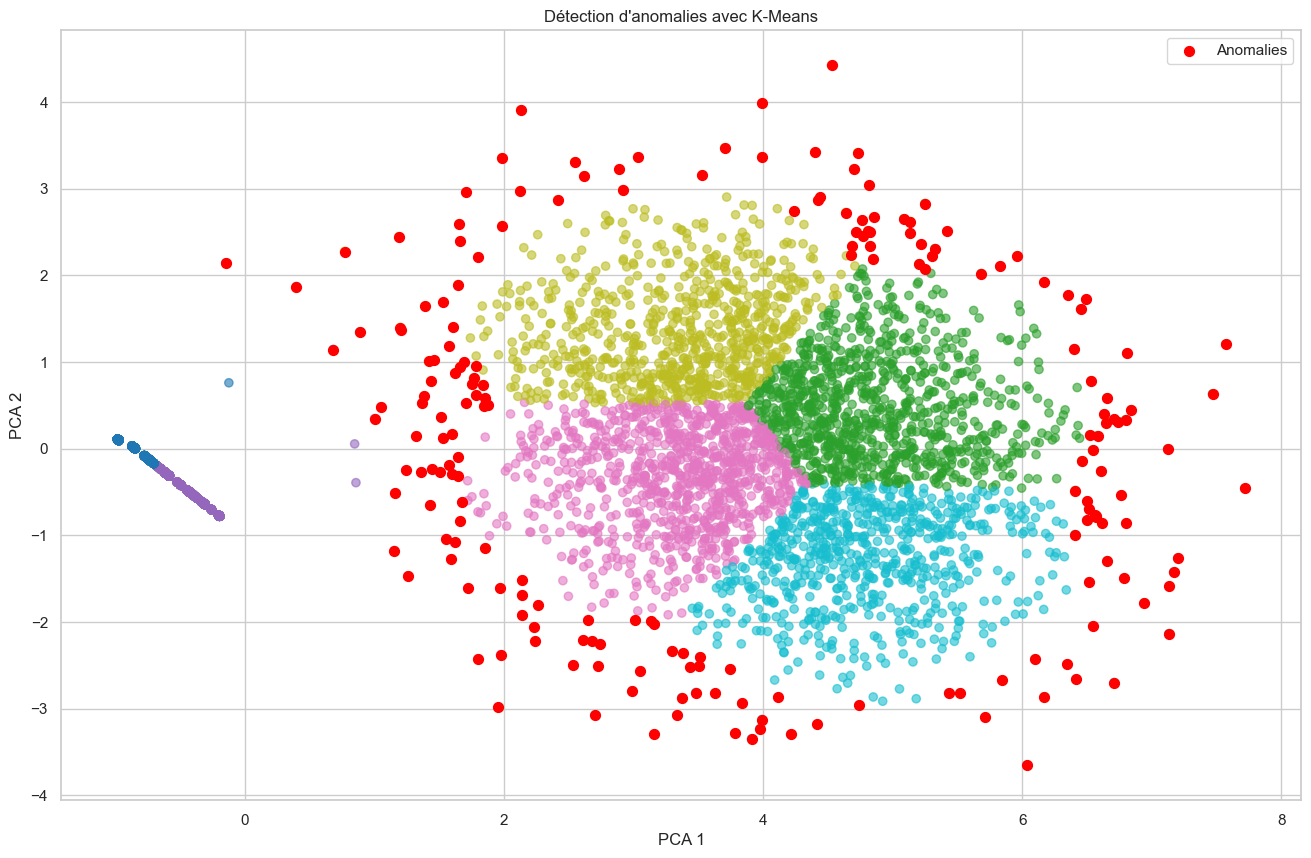

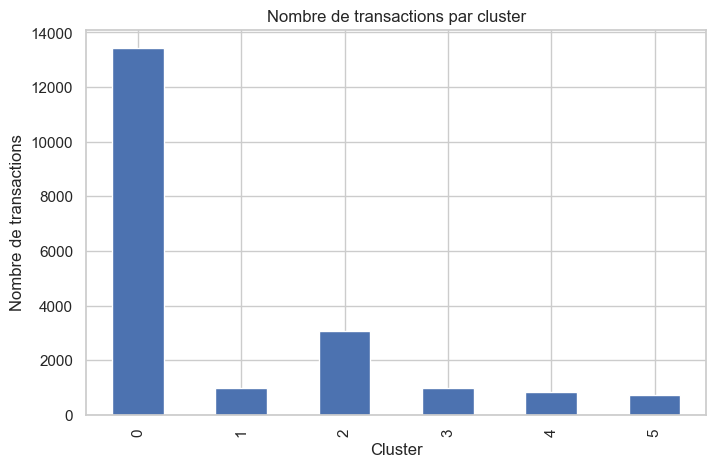

,cluster,transactions,initial_amount_mean,transfer_amount_mean,amount_received_mean,final_amount_mean,anomalies
0,0,13429,389.989799,369.200894,350.094804,50.720763,4
1,1,967,247082.939544,33090.004624,33090.004624,213992.934919,38
2,2,3076,2255.854223,6430.760166,6430.760166,-4174.905943,9
3,3,985,153769.128397,28472.878141,28472.878141,125296.250256,39
4,4,819,213190.717180,18003.910634,18003.910634,195186.806546,58
5,5,724,182312.197484,43558.082217,43558.082217,138754.115267,52


In [48]:
def main():
    df = load_data("transactions.csv")
    features = select_features(df)
    print("Features sélectionnées :", features.shape)

    normalized_data = normalize_features(features)
    model, labels = apply_kmeans(normalized_data, n_clusters=6)

    distances = np.linalg.norm(
        normalized_data - model.cluster_centers_[labels],
        axis=1
    )

    threshold = np.percentile(distances, 99)
    print(f"Seuil de distance choisi (99e percentile) : {threshold:.3f}")

    anomalies = detect_anomalies(normalized_data, model, threshold)
    print(f"Nombre d'anomalies : {len(anomalies)}")

    print("Distribution des clusters :")
    print(pd.Series(labels).value_counts().sort_index())

    plot_clusters(normalized_data, labels, anomalies)
    
    # Répartition des transactions par cluster
    plt.figure(figsize=(8,5))
    pd.Series(labels).value_counts().sort_index().plot(kind="bar")

    plt.title("Nombre de transactions par cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Nombre de transactions")
    plt.show()

    cluster_summary = analyze_clusters(features, labels, anomalies)
    return cluster_summary


if __name__ == "__main__":
    main()

## Étape 8 : Interprétation des résultats et rapport

L'analyse porte sur les clusters et les anomalies détectées afin de mieux comprendre les comportements financiers.

- Nombre de clusters : 6
- Nombre d'anomalies : 200

Répartition des transactions par cluster

Le graphique de répartition ainsi que les résultats numériques montrent que le cluster 0 regroupe la majorité des transactions avec 13 429 opérations. Le cluster 2 contient 3 076 transactions tandis que les clusters 1, 3, 4 et 5 sont beaucoup moins représentés.


Pour chaque cluster, analyser :
- les montants moyens `initial_amount`, `transfer_amount`, `amount_received`, `final_amount`
- le comportement général du groupe

Interprétation des clusters

Le cluster 0 contient 13 429 transactions et représente la majorité des opérations observées. Les montants moyens y sont faibles (initial_amount environ 390 et transfer_amount environ 369) et seulement 4 anomalies ont été détectées. Ce cluster correspond donc à des transactions courantes et relativement stables.

Le cluster 2 contient 3 076 transactions. On remarque que le montant moyen transféré est supérieur au montant initial disponible, ce qui entraîne un solde final moyen négatif (-4174,91). Ce comportement peut correspondre à des situations de découvert ou à des opérations nécessitant une attention particulière.

Les clusters 1, 3, 4 et 5 regroupent des transactions de montants beaucoup plus élevés. Ils représentent probablement des opérations financières importantes ou des comptes à forte activité. Les soldes finaux moyens restent élevés dans ces groupes.

Analyse des anomalies

Le modèle a détecté 200 anomalies, soit environ 1 % de l'ensemble des transactions. Ces anomalies correspondent aux transactions les plus éloignées du centre de leur cluster.

Les anomalies sont principalement concentrées dans les clusters 4 et 5, qui comptent respectivement 58 et 52 anomalies. Les clusters 1 et 3 présentent également un nombre important d'anomalies. À l'inverse, le cluster 0 contient très peu de transactions anormales.

Le graphique obtenu après réduction de dimension avec PCA montre que les anomalies se situent principalement à la périphérie des groupes, ce qui confirme leur caractère atypique.

Conclusion

L'utilisation de l'algorithme K-Means a permis de répartir les 20 000 transactions en six groupes représentant différents comportements financiers. L'analyse des distances aux centroïdes a permis d'identifier 200 transactions atypiques. Les résultats montrent que les opérations de montants élevés présentent davantage de comportements inhabituels que les transactions courantes. Une surveillance particulière des clusters contenant le plus d'anomalies est recommandée afin de détecter d'éventuelles opérations suspectes.